In [1]:
import os, time

import math
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable 

from skrmt.ensemble.spectral_law import MarchenkoPasturDistribution

# Following options are dependant on https://github.com/chanjure/global_chanju.git
# However, this is just an aesthetic package for plotting, so it is not necessary.
from global_chanju.paulplot.styles import nice_style
from global_chanju.paulplot.rc_setter import set_rc
from global_chanju.paulplot.rc_setter import get_rc
from global_chanju.utils.statistics import asym_err
from global_chanju.utils.statistics import f_bin
from global_chanju.paulplot.styles import base_ten


set_rc() # Setting global chanju plotting scheme

In [2]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=200):
    new_cmap = LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

# 0. Linear Full Batch

In [3]:
def A(epsilon, t=1):
    """ Variance rescaling
    """
    return (1 - epsilon)**(2*t)

def B(epsilon, t=1):
    """ Signal rescaling
    """
    return (1 - (1 - epsilon)**t)**2

def sigma2_t(epsilon, sigma_W, t):
    """ Rescaled bulk
    
    sigma_W: initial standard deviation of weight
    """
    return A(epsilon=epsilon, t=t) * sigma_W**2

def theta2_t(epsilon, sigma_W, r, t):
    """ Effective signal strength
    """
    return sigma2_t(epsilon=epsilon, sigma_W=sigma_W, t=t)*r + B(epsilon=epsilon, t=t)

def epsilon_c(sigma_W, r, t):
    """ Critical epsilon
    """
    return 1. - (1 + sigma_W * r**(0.25))**(-1./t)

def epsilon_c_n(sigma_W, r, t):
    eps_n = np.where(1. - (1 - sigma_W * r**(0.25))**(-1./t)>0, 1. - (1 - sigma_W * r**(0.25))**(-1./t), np.nan)
    return eps_n

def lambda_iso(epsilon, sigma_W, r, t):
    """ Location of isolated eigenvalue
    """
    a = sigma2_t(epsilon=epsilon, sigma_W=sigma_W, t=t)
    b = B(epsilon=epsilon, t=t)
    return (b + r*a)*(b + a) / b

def lambda_plus(epsilon, sigma_W, r, t=1):
    """Upper bound of the MP distribution

    Parameters:
    -----------
    r (int): Aspect ratio
    epsilon (float): step size
    sigma_W (float): Initial variance of the weight matrix   
    """
    return (1 - epsilon)**2 * sigma_W**2 * (1 + np.sqrt(r))**2

def t_c(epsilon, sigma_W, r):
    """ Critical time for dynamical BBP
    """
    return - np.log(1 + sigma_W * r**(0.25))/np.log(1 - epsilon)

def q2(epsilon, sigma_W, r, t=1):
    """ q2 Overlap
    """
    a = sigma2_t(epsilon=epsilon, sigma_W=sigma_W, t=t)
    b = B(epsilon=epsilon, t=t)
    c = b / a
    return (1. - r / c**2)/(1. + r / c)

In [4]:
plot_dir0 = "../../collected_results/figures/0.linear_full_batch/"
data_dir0 = "../../data/0.linear_full_batch/"

os.system("mkdir -p " + plot_dir0)
os.system("mkdir -p " + data_dir0)

0

## BBP phase diagram

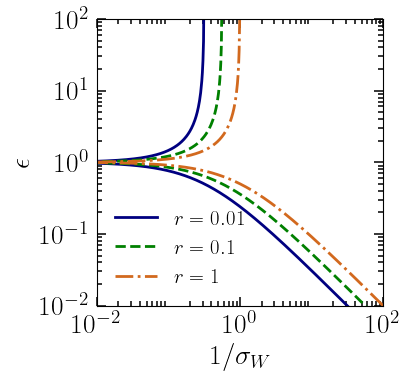

In [5]:
figure_id = "phase_boundary_r"

set_rc(scale=1.1)

sigma_list = np.logspace(-2, 2, 500)

r_list = [0.01, 0.1, 1]
colours = ['navy', 'green', 'chocolate']
lines = ['-', '--', '-.']
labels = ['0.01', '0.1', '1']
x_plot = 1./sigma_list

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']))


for i, r in enumerate(r_list):
    axs.plot(x_plot, epsilon_c(sigma_list, r, t=1),
             color=colours[i], ls=lines[i], 
             lw=2,
             marker='',
             label=r"$r = %s$"%(labels[i])
            )
    val_epsc_n = np.where(epsilon_c_n(sigma_list, r, t=1)>1e-15, epsilon_c_n(sigma_list, r, t=1), np.nan)
    axs.plot(x_plot, val_epsc_n,
             color=colours[i], ls=lines[i], 
             lw=2,
             marker='',
            )

nice_style(axs,
           logy=True, logx=True,
           xlim=(1e-2, 1e2), ylim=(1e-2, 1e2),
           xlabel=r"$1/\sigma_W$", ylabel=r"$\epsilon$"
          )

plt.legend(loc="lower left", fontsize=15)
plt.tight_layout()

axs.set_aspect("equal", adjustable="box")

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")
plt.show()

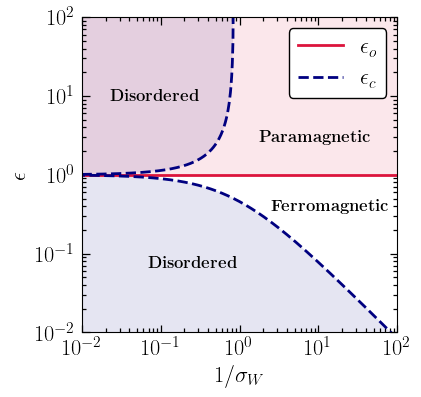

In [6]:
set_rc(scale=0.9)

figure_id = "phase_boundary"

sigma_list = np.logspace(-2, 2, 500)

x_plot = 1./sigma_list

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']))

epsilon_o = np.ones_like(sigma_list)
axs.plot(x_plot, epsilon_o, 
         color='crimson', ls='-', lw=2,
         marker='',
         label=r"$\epsilon_o$"
        )

axs.plot(x_plot, epsilon_c(sigma_list, r=0.5, t=1),
         color="navy", ls="--", lw=2,
         marker='',
         label=r"$\epsilon_c$"
        )
axs.plot(x_plot, epsilon_c_n(sigma_list, r=0.5, t=1),
         color="navy", ls="--", lw=2,
         marker='',
        )

axs.fill_between(1./sigma_list, y1=1e-2, y2=epsilon_c(sigma_list, r=0.5, t=1), 
                 facecolor='navy', alpha=0.1, hatch='')
axs.fill_between(1./sigma_list, y1=epsilon_c_n(sigma_list, r=0.5, t=1), y2=1e2, 
                 facecolor='navy', alpha=0.1, hatch='')
axs.fill_between(1./sigma_list, y1=epsilon_o, y2=1e2, 
                 facecolor='crimson', alpha=0.1, hatch='')

fontsize=12

axs.text(
    0.09, 0.75,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Disordered",
    fontsize=fontsize
)

axs.text(
    0.56, 0.62,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Paramagnetic",
    fontsize=fontsize
)

axs.text(
    0.6, 0.4,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Ferromagnetic",
    fontsize=fontsize
)

axs.text(
    0.21, 0.22,
    transform=axs.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"\bf Disordered",
    fontsize=fontsize
)

nice_style(axs,
           logy=True, logx=True,
           xlim=(1e-2, 1e2), ylim=(1e-2, 1e2),
           xlabel=r"$1/\sigma_W$", ylabel=r"$\epsilon$"
          )

plt.legend(loc='upper right', 
           facecolor='white', frameon=True, framealpha=1, 
           edgecolor='k', fancybox=True,
#            fontsize=18
          )

axs.set_aspect("equal", adjustable="box")

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")
plt.show()

## Eigenvector overlap

In [7]:
sigma = 1.
epsilon_list = np.linspace(0, 1.5, 30)

n = 101 # n_samples

N = 100
M = 200
r = N / M

figure_id = "q2_overlap_N%d"%(N)

u = np.random.normal(0., 1., size=(N))
u /= np.linalg.norm(u)
v = np.random.normal(0., 1., size=(M))
v /= np.linalg.norm(v)
W_star = np.einsum("ni, nj -> nij", [u]*n, [v]*n)

try:
    
    with np.load(data_dir0+"fig_"+figure_id+".npz") as data:
        x_plot = data["x_plot"]
        y_mean = data["y_mean"]
        y_err = data["y_err"]
        x_list = data["x_list"]
        q2_list = data["q2_list"]
        u_list = data["u_list"]
        
    print("Loaded the figure from "+data_dir0+"fig_"+figure_id+".npz")
    
except:
    x_list = np.zeros((len(epsilon_list), n, N))
    q2_list = np.zeros((len(epsilon_list), n))
    u_list = np.zeros((len(epsilon_list), n, N))

    for e, epsilon in enumerate(epsilon_list):
        print("measuring ", e, epsilon)
        W_ = np.random.normal(0., sigma/np.sqrt(M), size=(n, N, M))

        dl = - (W_star - W_)

        W_ -= epsilon * dl
        Xp = np.einsum("nac, nbc -> nab", W_, W_)
        x, u_ = np.linalg.eig(Xp)
        x_list[e] = x.copy()
        
        u_list[e] = u_[:, :, 0].copy()

        q2_ = np.sum(u_[:, :, 0] * u, axis=-1)**2
        q2_list[e] = q2_.copy()

    print("done")
    
    x_plot = epsilon_list
    med, err = asym_err(q2_list, axis=1)
    y_mean = med
    y_err = err
    
    np.savez(data_dir0+"fig_"+figure_id+".npz", 
             x_plot = x_plot,
             y_mean = y_mean,
             y_err = y_err,
             x_list = x_list,
             q2_list = q2_list,
             u_list = u_list,
            )
    print("Saved the figure to "+data_dir0+"fig_"+figure_id+".npz")

Loaded the figure from ../../data/0.linear_full_batch/fig_q2_overlap_N100.npz


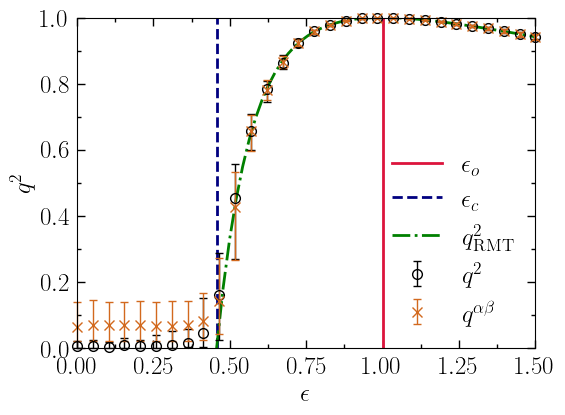

In [8]:
figure_id = "effective_orderparameter"

u_ab = []
for i in range(n):
    for j in range(i+1, n):
        u_ab.append(
            np.abs(
                np.sum(
                    u_list[:, i] * u_list[:, j], 
                    axis=-1
                )
            )
        )

        
u_ab = np.array(u_ab)

set_rc(scale=1.)

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

eps_0 = 1.
axs.axvline(eps_0,
            ls='-', color='crimson', lw=2,
            label=r"$\epsilon_o$")

eps_c = epsilon_c(sigma, r, t=1)
axs.axvline(eps_c, 
            ls='--', lw=2, color='navy',
            label=r"$\epsilon_c$")

x_q2 = np.linspace(eps_c, 1.5, 50)
q2_pred = q2(x_q2, 1., 0.5, t=1)
axs.plot(x_q2, q2_pred, 
         ls='-.', lw=2, marker='', color='green', 
         label=r"$q^2_{\rm RMT}$")

axs.errorbar(x_plot, y_mean, yerr=y_err, 
             ls='', clip_on=False,
             color='k', label=r"$q^2$")

med, err = asym_err(u_ab, axis=0)
axs.errorbar(epsilon_list, med, yerr=err,
             ls='', clip_on=False,
             color='chocolate', label=r"$q^{\alpha \beta}$")

nice_style(axs, 
           xlim=(0., max(epsilon_list)), ylim=(0.,1.), 
           xlabel=r"$\epsilon$", ylabel=r"$q^2$")

plt.legend(loc='lower right')

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")

plt.show()

## Isolated Eigenvalue

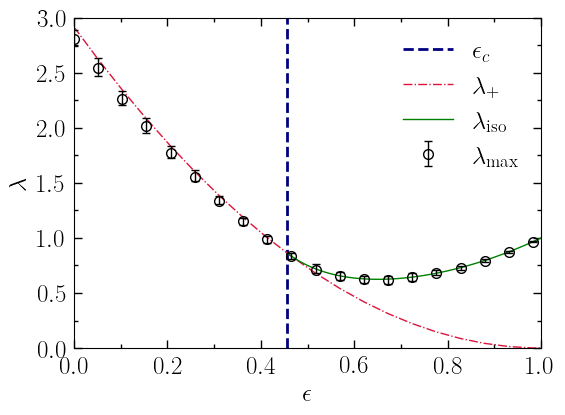

In [9]:
set_rc(scale=1.)

figure_id = "lbd_flow"

sigma = 1.
r = 0.5

eps_c = epsilon_c(sigma, r, t=1)

epsilon_list = np.linspace(0, 1.5, 30)

# MP edge
lambda_plus_plot = lambda_plus(epsilon_list, sigma, r)

# Top eigenvalue
lambda_top = np.max(x_list, axis=-1)

# Isolated eigenvalue
x_fine = np.linspace(eps_c, max(epsilon_list), 1000)
lambda_iso_plot = lambda_iso(x_fine, sigma, r=r, t=1)

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

# RMT critical epsilon
axs.axvline(eps_c, ls='--', lw=2,
            color='navy', label=r"$\epsilon_c$")

# MP edge
axs.plot(epsilon_list, lambda_plus_plot, ls='-.', 
         color='crimson', label=r"$\lambda_{+}$", marker='')

axs.plot(x_fine, lambda_iso_plot, 
         color='green', label=r"$\lambda_{\rm iso}$", ls='-', marker='')

# Experimental maximum eigenvalue
med, err = asym_err(lambda_top, axis=1)
axs.errorbar(epsilon_list, med, err, 
             color='k', clip_on=True,
             label=r"$\lambda_{\rm max}$", ls='')

nice_style(axs, xlim=(0., 1.), ylim=(0, 3), 
           xlabel=r"$\epsilon$", ylabel=r"$\lambda$")

plt.legend()

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")
plt.show()

## Numerical Simulation

In [10]:
# Need simulated data generated by linear_bbp3.py

def calculate_observables(data_dir, N, r, epsilon, sigma, alpha):
    # Load or generate data
    data_string = "dyn_N%d_r%.2f_eps%.5f_sig%.5f_alpha%d"%(N, r, epsilon, sigma, alpha)

    print("Loading " + data_string)

    with np.load(data_dir+data_string+"_data.npz") as data:
        u_top_local = data["u_top_list"] # n try, epochs+1, N
        q2_local = data["q2_list"]
        u_star_local = data["u_star"]
               
    q2_med, _ = asym_err(q2_local, axis=1)
    
    u_ab = []
    
    n_try = u_top_local.shape[1]
    for i in range(n_try):
        for j in range(i+1, n_try):
            u_ab.append(
                np.abs(
                    np.sum(
                        u_top_local[:,i] * u_top_local[:,j], 
                        axis=-1
                    )
                )
            )
            
    u_ab, _ = asym_err(u_ab, axis=0)
    
    return q2_med.reshape(-1), u_ab

In [11]:
epsilon_list = np.logspace(-2, 2, 20)
sigma_list = np.logspace(-2, 2, 20)
epochs = 4 # For aa
N = 100
alpha = 200

try:
    with np.load(data_dir0+"q2_diff_measure.npz") as data:
        q2_list = data["q2_list"]
        u_ab_list = data["u_ab_list"]
        
    print("Load from "+data_dir0 +"q2_diff_measure.npz")
        
except:
    q2_list = np.zeros((len(epsilon_list), len(sigma_list), epochs+1))
    u_ab_list = np.zeros((len(epsilon_list), len(sigma_list), epochs+1))

    for i, epsilon in enumerate(epsilon_list):
        for j, sigma in enumerate(sigma_list):
            q2_, u_ab_ = calculate_observables(
#                 data_dir0+"sb_data_e/", # u = e
                data_dir0+"sb_data_u/", # u = normal
                N, r,
                epsilon, sigma,
                alpha=alpha)

            q2_list[i, j] = q2_.copy()
            u_ab_list[i, j] = u_ab_.copy()
            
    np.savez(data_dir0+"q2_diff_measure.npz",
             q2_list = q2_list,
             u_ab_list = u_ab_list,
            )
    
    print("Saved to "+data_dir0 +"q2_diff_measure.npz")

print("done")

Load from ../../data/0.linear_full_batch/q2_diff_measure.npz
done


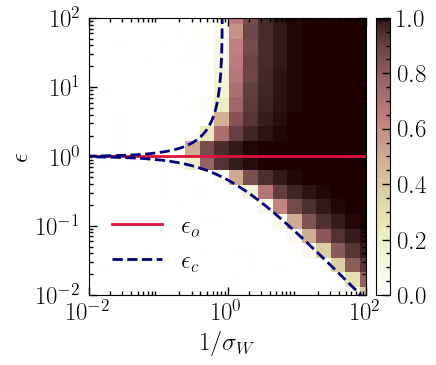

In [12]:
sigma_fine = np.logspace(-2, 2, 500)
eps_c = epsilon_c(sigma_fine, r=r, t=1)
eps_c_n = epsilon_c_n(sigma_fine, r=r, t=1)

set_rc(scale=1.)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(1./sigma_list, epsilon_list)

# Experimental phase diagram
im = axs.pcolormesh(X, Y, q2_list[:, :, 0],
                    vmin=0, vmax=1,
                    cmap='pink_r',
                    shading='auto')

# Optimal epsilon
axs.plot(1./sigma_list, np.ones_like(sigma_list), 
         color='crimson', marker='', ls='-', lw=2, 
         label=r"$\epsilon_o$")

# Critical step size
axs.plot(1./sigma_fine, eps_c, 
         color='navy', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$")
axs.plot(1./sigma_fine, eps_c_n, 
         color='navy', marker='', ls='--', lw=2,)

plt.legend(loc='lower left', facecolor='white', frameon=False, framealpha=1, edgecolor='k', fancybox=True)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir0 + "linear_q2_exp.pdf", bbox_inches="tight")

plt.show()

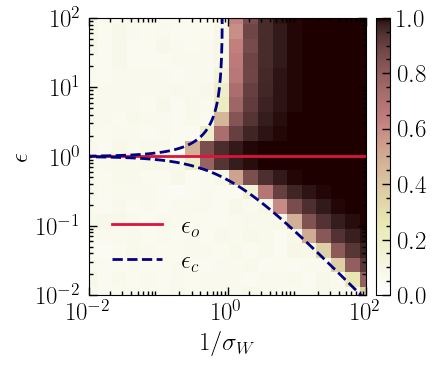

In [13]:
sigma_fine = np.logspace(-2, 2, 500)
eps_c = epsilon_c(sigma_fine, r=r, t=1)
eps_c_n = epsilon_c_n(sigma_fine, r=r, t=1)

set_rc(scale=1.)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

# Experimental phase diagram
im = axs.pcolormesh(1./X, Y, u_ab_list[:, :, 0],
                    vmin=0, vmax=1,
                    cmap='pink_r',
                    shading='auto')

# Optimal epsilon
axs.plot(1./sigma_list, np.ones_like(sigma_list), 
         color='crimson', marker='', ls='-', lw=2, 
         label=r"$\epsilon_o$")

# Critical step size
axs.plot(1./sigma_fine, eps_c, 
         color='navy', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$")
axs.plot(1./sigma_fine, eps_c_n, 
         color='navy', marker='', ls='--', lw=2,)

plt.legend(loc='lower left', facecolor='white', frameon=False, framealpha=1, edgecolor='k', fancybox=True)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir0 + "linear_u_ab_exp.pdf", bbox_inches="tight")

plt.show()

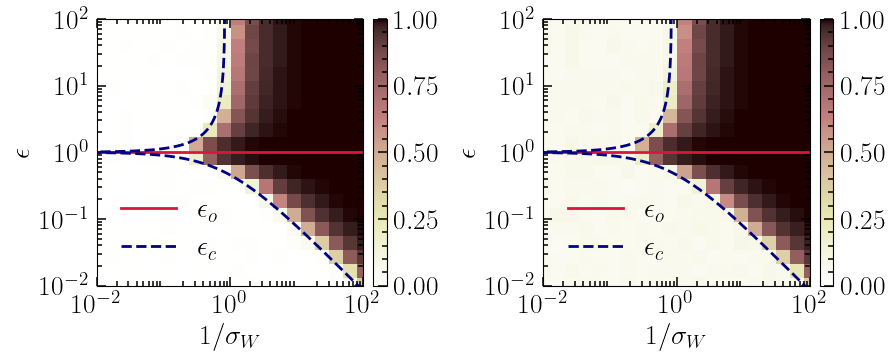

In [14]:
sigma_fine = np.logspace(-2, 2, 500)
eps_c = epsilon_c(sigma_fine, r=r, t=1)
eps_c_n = epsilon_c_n(sigma_fine, r=r, t=1)

set_rc(scale=1.1)
n_fig = 2

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

im = axs[0].pcolormesh(
    1./X, Y, q2_list[:, :, 0],
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

# Optimal epsilon
axs[0].plot(
    1./sigma_list, np.ones_like(sigma_list), 
    color='crimson', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)

# Critical step size
axs[0].plot(
    1./sigma_fine, eps_c, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
axs[0].plot(
    1./sigma_fine, eps_c_n, 
    color='navy', marker='', ls='--', lw=2,
)

axs[0].legend(
    loc='lower left', 
    facecolor='white', 
    frameon=False, 
    framealpha=1, 
    edgecolor='k', 
    fancybox=True
)

nice_style(axs[0], 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs[0].set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)


# Experimental phase diagram
im = axs[1].pcolormesh(
    1./X, Y, u_ab_list[:, :, 0],
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

# Optimal epsilon
axs[1].plot(
    1./sigma_list, np.ones_like(sigma_list), 
    color='crimson', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)

# Critical step size
axs[1].plot(
    1./sigma_fine, eps_c, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
axs[1].plot(
    1./sigma_fine, eps_c_n, 
    color='navy', marker='', ls='--', lw=2,
)

axs[1].legend(
    loc='lower left', 
    facecolor='white', 
    frameon=False, 
    framealpha=1, 
    edgecolor='k', 
    fancybox=True
)

nice_style(axs[1], 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs[1].set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir0 + "linear_exp_all.pdf", bbox_inches="tight")

plt.show()

# 1. Linear Full batch dynamics

## Running $\epsilon_c$

/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_28212/2185999806.py:29: RuntimeWarning: invalid value encountered in power
  eps_n = np.where(1. - (1 - sigma_W * r**(0.25))**(-1./t)>0, 1. - (1 - sigma_W * r**(0.25))**(-1./t), np.nan)


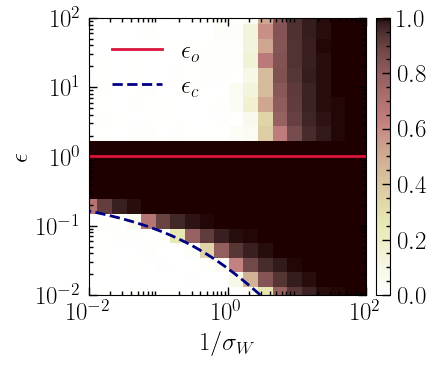

In [15]:
sigma_fine = np.logspace(-2, 2, 500)
eps_c = epsilon_c(sigma_fine, r=r, t=25)
eps_c_n = epsilon_c_n(sigma_fine, r=r, t=25)

set_rc(scale=1)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

# Experimental phase diagram
im = axs.pcolormesh(1./X, Y, q2_list[:, :, 1],
# im = axs.pcolormesh(1./X, Y, u_ab_list[:, :, -1],
                    vmin=0, vmax=1,
                    cmap='pink_r',
                    shading='auto')

# Optimal epsilon
axs.plot(1./sigma_list, np.ones_like(sigma_list), 
         color='crimson', marker='', ls='-', lw=2, 
         label=r"$\epsilon_o$")

# Critical step size
axs.plot(1./sigma_fine, eps_c, 
         color='navy', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$")
axs.plot(1./sigma_fine, eps_c_n, 
         color='navy', marker='', ls='--', lw=2,)

plt.legend(loc='upper left', facecolor='white', frameon=False, framealpha=1, edgecolor='k', fancybox=True)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir0 + "linear_q2_exp_last%d.pdf"%(25), bbox_inches="tight")

plt.show()

/opt/miniconda3/envs/work/lib/python3.9/site-packages/global_chanju/paulplot/styles.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.figure.tight_layout()
/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_28212/2185999806.py:29: RuntimeWarning: invalid value encountered in power
  eps_n = np.where(1. - (1 - sigma_W * r**(0.25))**(-1./t)>0, 1. - (1 - sigma_W * r**(0.25))**(-1./t), np.nan)
/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_28212/1149129907.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


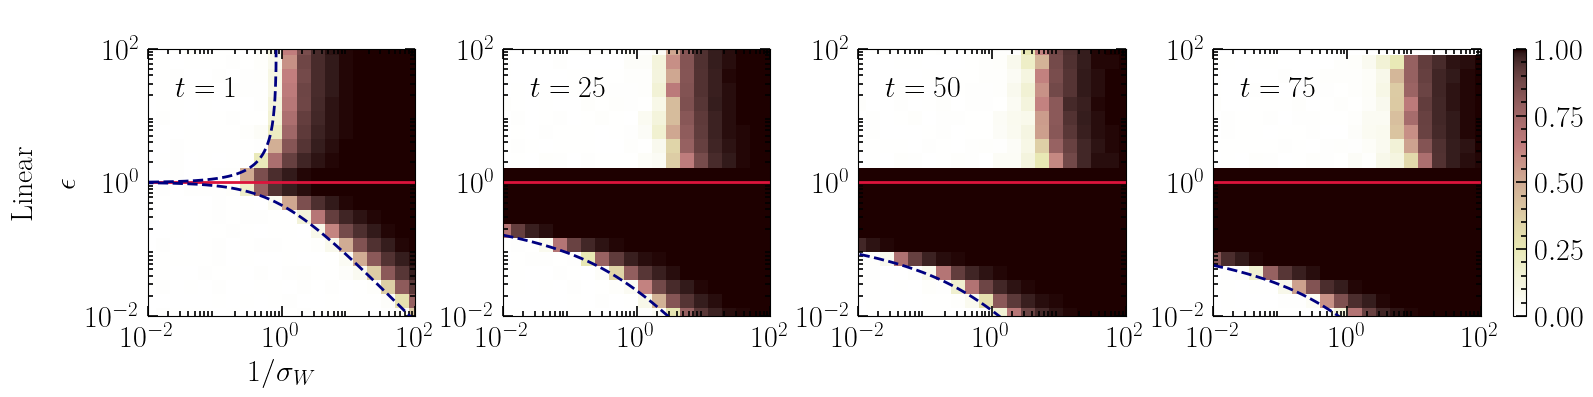

In [16]:
epoch_list = [1, 2, 3]
from matplotlib.gridspec import GridSpec

set_rc(scale=1.2)
n_fig = 5

fig = plt.figure(
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

sigma_fine = np.logspace(-2, 2, 500)
X, Y = np.meshgrid(sigma_list, epsilon_list)

gs = GridSpec(
    1, 5,
    width_ratios=[0.1, 1, 1, 1, 1],
    wspace=0.4
)

ax_title = fig.add_subplot(gs[0, 0])
ax_title.axis("off")

ax_title.text(
    0.5, 0.5,
    "Linear",
    rotation=90,
    va='center',
    ha='center',
#     fontsize=16
)

axes = []
pcm = None

# Initial
ax = fig.add_subplot(gs[0, 1])

pcm = ax.pcolormesh(
    1./X, Y, 
    q2_list[:, :, 0],
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

# Optimal epsilon
ax.plot(
    1./sigma_list, np.ones_like(sigma_list), 
    color='crimson', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)


eps_c = epsilon_c(sigma_fine, r=r, t=1)
eps_c_n = epsilon_c_n(sigma_fine, r=r, t=1)
# Critical step size
ax.plot(
    1./sigma_fine, eps_c, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
ax.plot(
    1./sigma_fine, eps_c_n, 
    color='navy', marker='', ls='--', lw=2,
)

ax.text(
    0.1, 0.85,
    transform=ax.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"$t=1$"
)

nice_style(
    ax, 
    ylim=(1e-2, 1e2),
    xlim=(1e-2, 1e2),
        xlabel=r"$1/\sigma_W$",
        ylabel=r"$\epsilon$",
    logx=True, logy=True,
    xticks=[1e-2, 1e0, 1e2], yticks=[1e-2, 1e0, 1e2]
)

ax.set_aspect('equal')

axes.append(ax)

for i, epoch in enumerate(epoch_list):
    ax = fig.add_subplot(gs[0, i+2])
    eps_c = epsilon_c(sigma_fine, r=r, t=epoch*25)
    eps_c_n = epsilon_c_n(sigma_fine, r=r, t=epoch*25)

    pcm = ax.pcolormesh(
        1./X, Y, 
        q2_list[:, :, epoch],
        vmin=0, vmax=1,
        cmap='pink_r',
        shading='auto'
    )
    
    # Optimal epsilon
    ax.plot(1./sigma_list, np.ones_like(sigma_list), 
             color='crimson', marker='', ls='-', lw=2, 
             label=r"$\epsilon_o$")

    # Critical step size
    ax.plot(1./sigma_fine, eps_c, 
             color='navy', marker='', ls='--', lw=2,
             label=r"$\epsilon_c$")
    ax.plot(1./sigma_fine, eps_c_n, 
             color='navy', marker='', ls='--', lw=2,)
    
    ax.text(
        0.1, 0.85,
        transform=ax.transAxes,
        horizontalalignment='left', verticalalignment='center',
        color='k', 
        s=r"$t=%d$"%(epoch*25)
    )

    nice_style(
        ax, 
        ylim=(1e-2, 1e2),
        xlim=(1e-2, 1e2),
        logx=True, logy=True,
        xticks=[1e-2, 1e0, 1e2], yticks=[1e-2, 1e0, 1e2]
    )
    
    ax.set_aspect('equal')

    axes.append(ax)

    
cbar = fig.colorbar(
    pcm,
    ax=axes,
    location='right',
    shrink=0.77,
    pad=0.02
)

plt.tight_layout()

plt.savefig(plot_dir0+"linear_q2_time_dep.pdf")

plt.show()

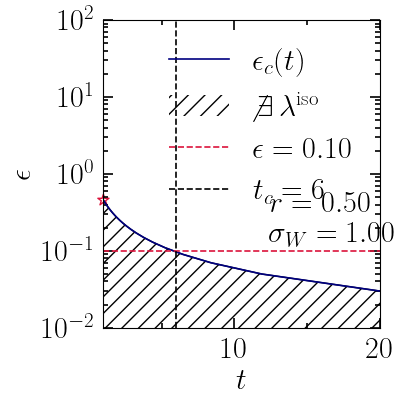

In [17]:
epsilon_list = np.linspace(0.01, 0.99, 50)
sigma = 1.
r = 0.5

epsilon = 0.1

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']))

t_list = t_c(epsilon_list, sigma_W=sigma, r=r)

axs.plot(t_list, epsilon_list, 
         ls='-', marker='', color='navy',
         label=r"$\epsilon_c (t)$"
        )

axs.scatter([1], epsilon_c(sigma_W=1, r=r, t=1),
            marker='*', facecolor='none', color='crimson',
            clip_on=False
           )

axs.fill_between(t_list, epsilon_list, 
                 facecolor='none', hatch="//",
                 label=r"$\not \exists \, \lambda^{\rm iso}$"
                )

axs.axhline(epsilon, ls='--', 
            color='crimson', 
            label=r"$\epsilon = %.2f$"%(epsilon))

t_crit = np.round(t_c(epsilon, sigma_W=sigma, r=r))
axs.axvline(t_crit, ymin=0, ymax=1.,
            ls='--', color='k',
            label=r"$t_c = %d$"%(t_crit)
           )

nice_style(axs,
           xlim=(1, 20), ylim=(1e-2,1e2),
           xlabel=r"$t$", ylabel=r"$\epsilon$",
           logy=True
          )

axs.text(0.6, 0.3,
            transform=axs.transAxes,
            horizontalalignment='left', verticalalignment='center',
            color='k', 
            s=r"$\sigma_W = %.2f$"%(sigma)
           )

axs.text(0.6, 0.4,
            transform=axs.transAxes,
            horizontalalignment='left', verticalalignment='center',
            color='k', 
            s=r"$r = %.2f$"%(r)
           )

plt.legend(loc="upper right")

plt.tight_layout()

plt.savefig(plot_dir0+"linear_running_eps.pdf")

plt.show()

## Time dependent phase diagram

/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_28212/2095126726.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


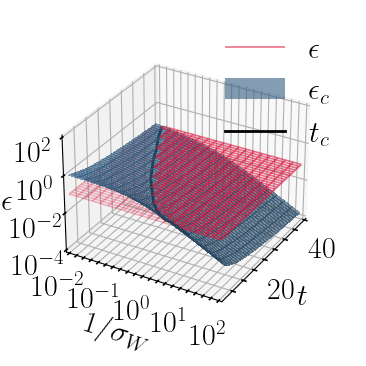

In [18]:
# epsilon = 0.01
epsilon = 0.1
# epsilon = 0.25

t_max = 40
t_list = np.arange(1, t_max)

sigma_list = np.logspace(-2, 2, 20)
   
XX, YY = np.meshgrid(t_list, sigma_list)
eps_c_list = epsilon_c(sigma_W=1./YY, r=r, t=XX)

def const_eps(x, y, eps):
    return 0.5*(x/x + y/y)*eps # To keep the shape

eps_init = const_eps(XX, YY, epsilon)

t_c_list = np.round(t_c(epsilon=epsilon, sigma_W=sigma_list, r=r))

valid1 = np.where(t_c_list > 0, t_c_list, np.nan)
valid_t = np.where(valid1 < t_max, valid1, np.nan)
eps_t_c_list = np.zeros((len(sigma_list)))
for i in range(len(sigma_list)):
    eps_t_c_list[i] = epsilon_c(sigma_W=sigma_list[i], r=r, t=valid_t[i])

n_fig = 1
fig = plt.figure(figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']))

ax = fig.add_subplot(projection='3d')

z1_masked = np.where(np.log10(eps_init) > np.log10(eps_c_list), np.log10(eps_init), np.nan)
z2_masked = np.where(np.log10(eps_init) < np.log10(eps_c_list), np.log10(eps_init), np.nan)

ax.plot_wireframe(XX, np.log10(YY), z1_masked, 
                  color='crimson', alpha=0.6, label=r"$\epsilon$")

ax.plot_wireframe(XX, np.log10(YY), z2_masked, 
                  color='crimson', alpha=0.3)

ax.plot_surface(XX, np.log10(YY), np.log10(eps_c_list), 
                color='steelblue', alpha = 0.6,
                rstride=1, cstride=1, antialiased=False,
                linewidth=1, shade=True,
                label=r"$\epsilon_c$")

ax.plot3D(valid_t, np.log10(1./sigma_list), np.log10(eps_t_c_list),
        marker='', lw=2, color='k', label=r"$t_c$")

ax.set_xlabel(r"$t$", labelpad=10)
ax.set_ylabel(r"$1/\sigma_W$", labelpad=15)
ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r"$\epsilon$", labelpad=8, rotation=0)

ax.set_xlim(t_max, 1)
ax.set_ylim(-2, 2)
ax.set_zlim(-4, 2)

y_ticks = [[-2,-1,0,1,2],[r"$10^{-2}$",r"$10^{-1}$",r"$10^{0}$",r"$10^{1}$",r"$10^{2}$"]]
ax.set_yticks(y_ticks[0], y_ticks[1])

z_ticks = [[-4,-2,0,2],
           [r"$10^{-4}$",r"$10^{-2}$",r"$10^{0}$",r"$10^{2}$"]]
ax.set_zticks(z_ticks[0], z_ticks[1])

ax.view_init(azim=30, elev=30)
ax.set_box_aspect(None, zoom=0.80)

plt.legend()

plt.tight_layout()

plt.savefig(plot_dir0 + "linear_phase_3d_eps%.2f.pdf"%(epsilon))

plt.show()

# Finite size scaling

measuring  0 0.4
measuring  1 0.4105263157894737
measuring  2 0.4210526315789474
measuring  3 0.43157894736842106
measuring  4 0.4421052631578948
measuring  5 0.45263157894736844
measuring  6 0.4631578947368421
measuring  7 0.4736842105263158
measuring  8 0.4842105263157895
measuring  9 0.49473684210526314
measuring  10 0.5052631578947369
measuring  11 0.5157894736842106
measuring  12 0.5263157894736842
measuring  13 0.5368421052631579
measuring  14 0.5473684210526315
measuring  15 0.5578947368421052
measuring  16 0.5684210526315789
measuring  17 0.5789473684210527
measuring  18 0.5894736842105264
measuring  19 0.6
done
Saved the figure to ../../data/0.linear_full_batch/q2_overlap_fss_N1024.npz


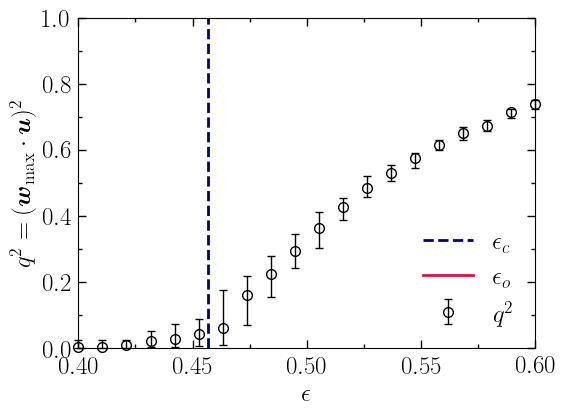

In [62]:
sigma = 1.
epsilon_list = np.linspace(0.4, 0.6, 20)

n = 50

# N = 128
# N = 256
# N = 512
N = 1024

M = N*2
r = N / M

figure_id = "q2_overlap_fss_N%d"%(N)

np.random.seed(42)
u = np.random.normal(0., 1, size=(N))
u /= np.linalg.norm(u)
v = np.random.normal(0., 1, size=(M))
v /= np.linalg.norm(v)

W_star = np.einsum("i, j -> ij", u, v)

try:
    asdf
    with np.load(data_dir0+figure_id+".npz") as data:
        x_plot = data["x_plot"]
        y_mean = data["y_mean"]
        y_err = data["y_err"]
        x_list = data["x_list"]
        
    print("Loaded the figure from "+data_dir0+figure_id+".npz")
    
except:
    x_list = np.zeros((len(epsilon_list), n, N))
    q2_list = np.zeros((len(epsilon_list), n))

    for e, epsilon in enumerate(epsilon_list):
        print("measuring ", e, epsilon)
        W0 = np.random.normal(0., sigma/np.sqrt(M), size=(n, N, M))

        dl = - (W_star - W0)

        W_prime = W0 - epsilon * dl
        Xp = np.einsum("nac, nbc -> nab", W_prime, W_prime)
        x, u_ = np.linalg.eig(Xp)
        x_list[e] = x.copy()

        q2_ = (u_[:, :, 0] @ u)**2
        q2_list[e] = q2_.copy()

    print("done")
    
    x_plot = epsilon_list
    med, err = asym_err(q2_list, axis=1)
    y_mean = med
    y_err = err
    
    np.savez(data_dir0+figure_id+".npz", 
             x_plot = x_plot,
             y_mean = y_mean,
             y_err = y_err,
             x_list = x_list,
             q2_list = q2_list
            )
    print("Saved the figure to "+data_dir0+figure_id+".npz")


set_rc(scale=1)
n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

eps_c = epsilon_c(sigma, r, t=1)
axs.axvline(eps_c, 
            ls='--', lw=2, color='navy',
            label=r"$\epsilon_c$")

eps_0 = 1.
axs.axvline(eps_0,
            ls='-', color='crimson', lw=2,
            label=r"$\epsilon_o$")


axs.errorbar(x_plot, y_mean, yerr=y_err, 
             ls='', clip_on=False,
             color='k', label=r"$q^2$")


nice_style(axs, 
           xlim=(0.4, 0.6), ylim=(0.,1.), 
           xlabel=r"$\epsilon$", ylabel=r"$q^2 = (\boldsymbol{w}_{\rm max} \cdot \boldsymbol{u})^2$")

plt.legend(loc='lower right')

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")

plt.show()

In [63]:
# L_list = np.array([25, 50, 100, 200]) # 1000 samples
L_list = np.array([128, 256, 512, 1024]) # 50 samples
figure_ids = ["q2_overlap_fss_N%d"%(d) for d in L_list]
x_plots = []
q2_fss = []

for fig_id in figure_ids:
    with np.load(data_dir0+fig_id+".npz") as data:
        print(fig_id)
        x_plots.append(data["x_plot"])
        q2_fss.append(data["q2_list"])

q2_fss = np.array(q2_fss)

q2_overlap_fss_N128
q2_overlap_fss_N256
q2_overlap_fss_N512
q2_overlap_fss_N1024


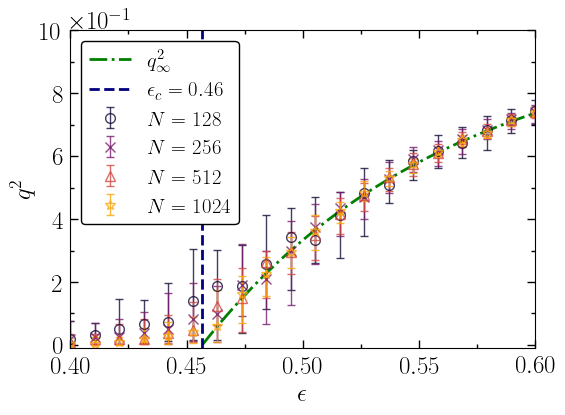

In [64]:
set_rc(scale=1)

figure_id = "q2_overlap_fss"

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))


eps_c = epsilon_c(sigma_W=1., r=0.5, t=1)
x_q2 = np.linspace(eps_c, 0.6, 100)
q2_pred = q2(x_q2, sigma_W=sigma, r=r, t=1)

axs.plot(x_q2, q2_pred, 
         marker='', lw=2, ls='-.', color='green', label=r"$q^2_{\infty}$")

axs.axvline(eps_c, ls='--', color='navy', lw=2,
            label=r"$\epsilon_c = %.2f$"%(eps_c))

# cmap = plt.cm.inferno_r(np.linspace(0.2, 0.9, len(L_list)))
cmap = plt.cm.inferno(np.linspace(0.1, 0.8, len(L_list)))

mean, err = asym_err(q2_fss, axis=-1)

for i in range(len(L_list)):
    axs.errorbar(x_plot, mean[i], yerr=err[:,i], ls='',
                 color=cmap[i], label=r"$N=%d$"%(L_list[i]), alpha=0.8)

nice_style(axs, 
           xlim=(0.4, 0.6), ylim=(-0.01, 1.), 
           xlabel=r"$\epsilon$", 
           ylabel=r"$q^2$")

plt.legend(
#     bbox_to_anchor=(1., 1.),
    loc='upper left', 
    facecolor='white', 
    framealpha=1, frameon=True, edgecolor='k', fontsize=15)

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")

plt.show()

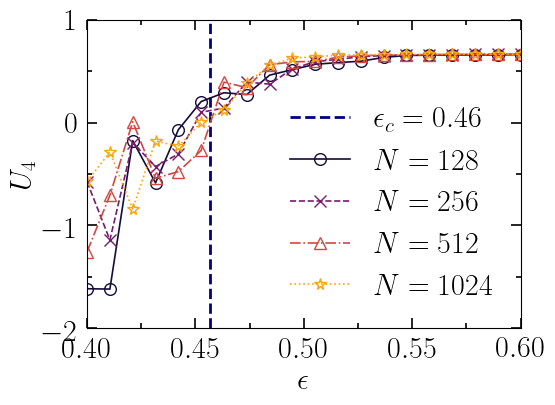

In [65]:
set_rc(scale=1.2)

U4 = 1. - np.mean(q2_fss**4, axis=-1)/(3. * np.mean(q2_fss**2, axis=-1)**2)

figure_id = "U4_fss"

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

ec_t = epsilon_c(sigma_W=1., r=0.5, t=1)

axs.axvline(ec_t, ls='--', color='navy', lw=2,
            label=r"$\epsilon_c = %.2f$"%(ec_t))

for i in range(len(L_list)):
    axs.plot(x_plot, U4[i], color=cmap[i], label=r"$N=%d$"%(L_list[i]))


nice_style(axs, 
           xlim=(0.4, 0.6), ylim=(-2., 1.), 
           xlabel=r"$\epsilon$", 
           ylabel=r"$U_4$")

plt.legend(loc='lower right', 
           facecolor='white', 
           framealpha=1., frameon=False, edgecolor='k')

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")

plt.show()

In [66]:
def rho(L, rho_inf, c, theta):
    return rho_inf + c / (np.asarray(L)**theta)

In [67]:
def pade22(x, a0, a1, a2, b1, b2):
    return (a0 + a1 * x + a2 * x**2)/(1 + b1 * x + b2 * x**2)

In [68]:
def pade11(x, a0, a1, b1):
    return (a0 + a1 * x)/(1 + b1 * x)

In [69]:
def chisq_res(params, datas, pade, eps, ls):
    gc, rho_inf, c, theta = params[:4]
    pade_params = params[4:]
    
    res = []
    raw_x_all = []
    raw_U4_all = []
    
    per_block = []
    
    rho_L = rho(ls, rho_inf, c, theta)
    L_term = ls[:, None] ** rho_L[:, None]
    g_term = (eps[None, :] - gc)
    
    x = g_term * L_term

    m2 = np.mean(datas**2, axis=(-1))
    m4 = np.mean(datas**4, axis=(-1))

    U4 = 1. - m4/(3. * m2**2)
    
    x_flat = x.ravel()
    U4_flat = U4.ravel()
    
    F = pade(x_flat, *pade_params)
    
    return U4_flat - F

In [70]:
from scipy.optimize import least_squares

In [97]:
ec_t = epsilon_c(sigma_W=1., r=0.5, t=1)

# Pade22 good
guess = [
    ec_t, # gc
    0.66, # nu
    0.5, # c
    1., # theta
    0.25, 1.6, 0.36, 0.1, 1.6 # pade coeffs
]

bounds = (
    [ec_t - 1, 
     0., # rho_inf
     -2, # c
     0.01, # theta
     -np.inf, -np.inf, -np.inf, # pade a
     -np.inf, -np.inf # pade b
    ],
    [ec_t + 1, 
     1., # rho_inf
     np.inf, # c
     10, # theta
     1., np.inf, 10, # pade a
     10, np.inf # pade b 
    ]
)

result = least_squares(
    chisq_res,
    guess,
    bounds = bounds,
    args=(q2_fss, pade22, x_plot, L_list),
#     method="trf"
)

ec = result.x[0]
print("ec", ec)
rho_inf = result.x[1]
print("rho_inf", rho_inf)
c = result.x[2]
print("c", c)
theta = result.x[3]
print("theta", theta)
pade_coeffs = result.x[4:]
print("pade coeffs", pade_coeffs)

ec 0.45081751682662813
rho_inf 1.2415622414277852e-05
c 2082.4504714228256
theta 2.0576639971285378
pade coeffs [  0.04295472  13.36161752 -18.63523849   5.34627905  25.85217957]


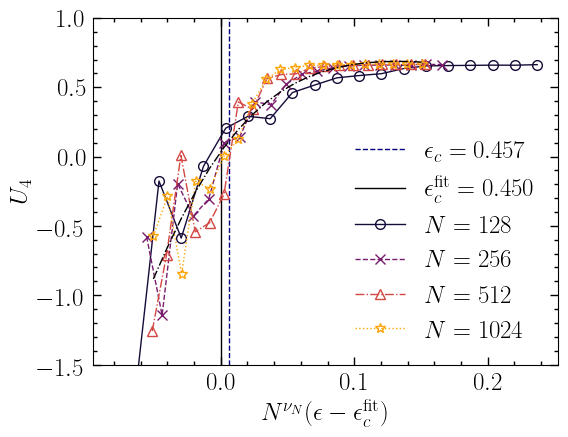

In [89]:
pade = pade22

plt.axvline(ec_t - ec, ls='--', label=r"$\epsilon_c = %.3f$"%(ec_t))
plt.axvline(0, ls='-', color='k', label=r"$\epsilon_c^{\rm fit} = %.3f$"%(ec))

rescale_L = L_list**rho(L_list, rho_inf, c, theta)

for i in range(len(L_list)):
    x_res = (x_plot - ec)*rescale_L[i]
    plt.plot(x_res, U4[i], color=cmap[i], label=r"$N=%d$"%(L_list[i]))

y_plot = pade(x_res, *pade_coeffs)
plt.plot(x_res, y_plot, color='k', alpha=1, marker='', ls='-.')

plt.legend()
plt.xlabel(r"$N^{\nu_N}(\epsilon - \epsilon_c^{\rm fit})$")
plt.ylabel(r"$U_4$")

# plt.xlim(-100, 100)
plt.ylim(-1.5, 1.)
plt.show()

In [99]:
# Jackknife

n = q2_fss.shape[-1]
q2_jk = np.empty((len(L_list), len(x_plot), n, n-1))
for L in range(len(L_list)):
    for e in range(len(x_plot)):
        for i in range(n):
            q2_jk[L,e,i] = np.r_[q2_fss[L,e,:i], q2_fss[L,e,i+1:]]

In [111]:
try:
    with np.load(data_dir0+"fss.npz") as file:
        results = file['results']
    print("Load")

except:
    results = np.zeros((n, len(guess)))

    # Pade22 good
    guess = [
        ec_t, # gc
        0.5, # rho_inf
        0.5, # c
        1., # theta
        0.25, 1.6, 0.36, 0.1, 1.6 # pade coeffs
    ]
    
    bounds = (
        [ec_t - 0.1, 
         0., # rho_inf
         -2, # c
         0.01, # theta
         -np.inf, -10, -np.inf, # pade a
         -np.inf, -np.inf # pade b
        ],
        [ec_t + 0.1, 
         1., # rho_inf
         10, # c
         10, # theta
         1., np.inf, 10, # pade a
         10, np.inf # pade b 
        ]
    )

    for i in range(n):
        guess = [
            ec_t, # gc
            np.random.uniform(0.4, 0.6), # rho_inf
            np.random.uniform(0.4, 0.6), # c
            np.random.uniform(0.8, 1.2), # theta
            np.random.uniform(0.1, 0.5), # a0
            np.random.uniform(1., 2.), # a1
            np.random.uniform(0.2, 0.5), # a2
            np.random.uniform(0.01, 0.5), # b1
            np.random.uniform(1., 2.) # b2
        ]

        result = least_squares(
            chisq_res,
            guess,
            bounds = bounds,
            args=(q2_jk[:,:,i], pade22, x_plot, L_list),
            method="trf"
        )

        if i % 10 == 0:
            print(i, result.x[0])

        results[i] = result.x.copy()
    np.savez(data_dir0+"fss.npz", results=results)
    print("Saved")

0 0.45418712018549484
10 0.4525209498651523
20 0.45297060091775915
30 0.4521835317671456
40 0.4538412924411192
Saved


0.45396534150118517
0.014805709714693303


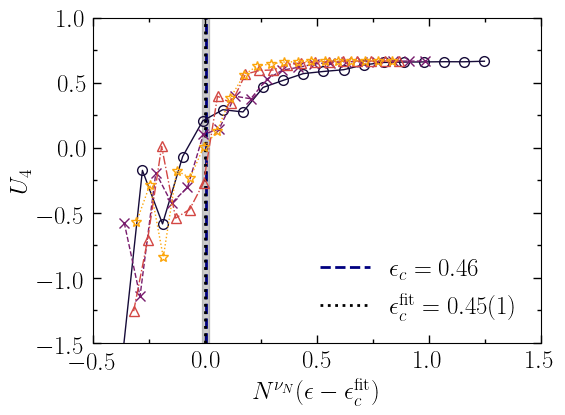

In [116]:
set_rc(scale=1)

means = np.mean(results, axis=0)
errs = np.sqrt(n - 1)*np.std(results, axis=0)
ec_jk = means[0]
ec_err_jk = errs[0]
print(ec_jk)
print(ec_err_jk)

rho_inf_jk = means[1]
c_jk = means[2]
theta_jk = means[3]

figure_id = "U4_fit_fss"

n_fig = 1
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

pade = pade22

axs.axvline(ec_t - ec_jk, ls='--', lw=2, color='navy',
            label=r"$\epsilon_c = %.2f$"%(ec_t))

axs.axvline(0, ls=':', lw=2, color='k',
            label=r"$\epsilon_c^{\rm fit} = %.2f (1)$"%(ec_jk))
axs.fill_between(np.linspace(-ec_err_jk, ec_err_jk), -1.5, 1, alpha=0.2, color='k')

rescale_L = L_list**rho(L_list, rho_inf_jk, c_jk, theta_jk)

for i in range(len(L_list)):
    x_res = (x_plot - ec_jk)*rescale_L[i]
    axs.plot(x_res, U4[i], color=cmap[i], )#label=r"$N=%d$"%(L_list[i]))

nice_style(axs, 
           xlim=(-0.5, 1.5), 
           ylim=(-1.5, 1.), 
           xlabel=r"$N^{\nu_N}(\epsilon - \epsilon_c^{\rm fit})$", 
           ylabel=r"$U_4$")

plt.legend(loc='lower right', 
           facecolor='white', 
           framealpha=1., frameon=False, edgecolor='k')

plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")

plt.show()

0.45396534150118517
0.014805709714693303


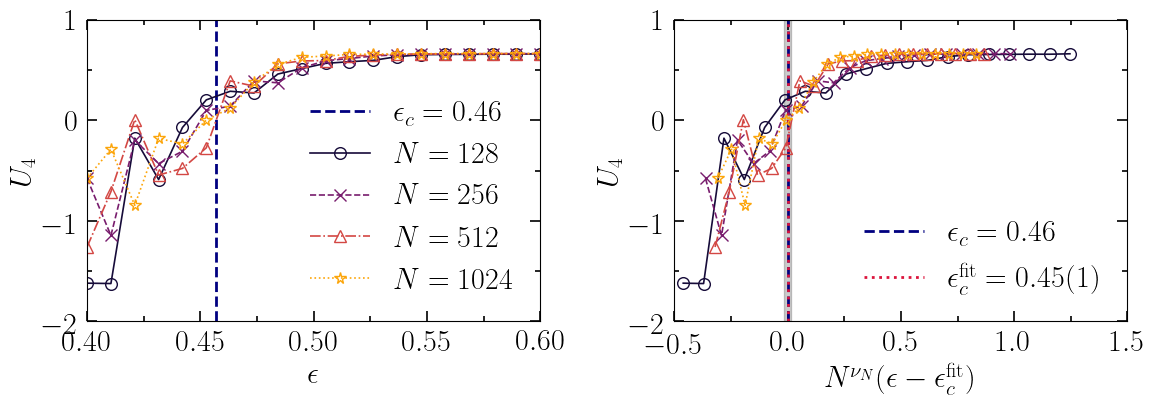

In [121]:
set_rc(scale=1.2)

U4 = 1. - np.mean(q2_fss**4, axis=-1)/(3. * np.mean(q2_fss**2, axis=-1)**2)

figure_id = "U4_fss_fit"

n_fig = 2
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r']))

ec_t = epsilon_c(sigma_W=1., r=0.5, t=1)

axs[0].axvline(ec_t, ls='--', color='navy', lw=2,
            label=r"$\epsilon_c = %.2f$"%(ec_t))

for i in range(len(L_list)):
    axs[0].plot(x_plot, U4[i], 
                color=cmap[i],
                label=r"$N=%d$"%(L_list[i]))


nice_style(axs[0], 
           xlim=(0.4, 0.6), ylim=(-2., 1.), 
           xlabel=r"$\epsilon$", 
           ylabel=r"$U_4$")

axs[0].legend(
    loc='lower right', 
    facecolor='white', 
    framealpha=1., frameon=False, edgecolor='k')

###########

means = np.mean(results, axis=0)
errs = np.sqrt(n-1)*np.std(results, axis=0)
ec_jk = means[0]
ec_err_jk = errs[0]
print(ec_jk)
print(ec_err_jk)

rho_inf_jk = means[1]
c_jk = means[2]
theta_jk = means[3]

pade = pade22

axs[1].axvline(ec_t - ec_jk, ls='--', lw=2, color='navy',
            label=r"$\epsilon_c = %.2f$"%(ec_t))

axs[1].axvline(0, ls=':', lw=2, color='crimson',
            label=r"$\epsilon_c^{\rm fit} = %.2f (1)$"%(ec_jk))
axs[1].fill_between(np.linspace(-ec_err_jk, ec_err_jk), -2, 1, alpha=0.2, color='k')

rescale_L = L_list**rho(L_list, rho_inf_jk, c_jk, theta_jk)

for i in range(len(L_list)):
    x_res = (x_plot - ec_jk)*rescale_L[i]
    axs[1].plot(x_res, U4[i], color=cmap[i])#label=r"$N=%d$"%(L_list[i]))

nice_style(axs[1], 
           xlim=(-0.5, 1.5), 
           ylim=(-2, 1.), 
           xlabel=r"$N^{\nu_N}(\epsilon - \epsilon_c^{\rm fit})$", 
           ylabel=r"$U_4$")

axs[1].legend(loc='lower right', 
           facecolor='white', 
           framealpha=1., frameon=False, edgecolor='k')


plt.tight_layout()

plt.savefig(plot_dir0+"linear_"+figure_id+".pdf")

plt.show()